In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from pathlib import Path
import glob
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
points = np.linspace(0, 200, 30000)

def crpic_vectorise(points, positions, hauteurs, largeur=0.02):
    points_col = points[:, np.newaxis]
    diff = points_col - positions[np.newaxis, :]
    lorentz = hauteurs[np.newaxis, :] * (largeur**2) / (diff**2 + largeur**2)
    return lorentz.sum(axis=1)

In [3]:
from pathlib import Path

SOLVANTS = {
    'cdcl3':   {'ppm': 77.16, 'Int.': 500},
    'ccl4':    None,
    'dmso-d6': {'ppm': 39.52, 'Int.': 700},
    'd2o':     None,   # D2O contains no carbon
}

molecules_dict = {}

def normaliser_intensites(df):
    max_int = df['Int.'].max()
    df['Int.'] = df['Int.'] / max_int * 1000
    return df

for dossier_solvant in glob.glob('/content/drive/MyDrive/IA RMN/Molecules CSV 13C/*/'):
    nom_solvant = Path(dossier_solvant).name.lower()
    pic_solvant = SOLVANTS.get(nom_solvant, None)

    for fichier in glob.glob(f'{dossier_solvant}*.csv'):
        nom = Path(fichier).stem.split('(')[0]
        try:
            df = pd.read_csv(fichier)[['ppm', 'Int.']]
            df = normaliser_intensites(df)
            molecules_dict[nom] = {'df': df, 'solvant': pic_solvant}
        except KeyError as e:
            print(f"Colonne manquante dans {fichier}: {e}")
            continue

print(f"Total : {len(molecules_dict)} molécules")

Total : 1244 molécules


In [4]:
import re
from collections import defaultdict

def normaliser_nom(nom):
    n = nom.lower().strip()
    n = re.sub(r'_hmdb\d+', '', n)
    n = re.sub(r'_cid\d+', '', n)
    n = re.sub(r'_\d{4,}', '', n)
    n = re.sub(r'^(dl|l|d|r|s|rel|cis|trans|\(\+\)|\(\-\)|\(\+/-\))[\-\s]', '', n)
    n = re.sub(r'^\d+[\-,]?(cis|trans)[\-\s]', '', n)
    n = re.sub(r'[\-\s_]+', '_', n)
    return n.strip('_')

groupes = defaultdict(list)
for nom in molecules_dict.keys():
    groupes[normaliser_nom(nom)].append(nom)

doublons = {k: v for k, v in groupes.items() if len(v) > 1}
print(f"{len(doublons)} groupes de doublons potentiels détectés")
for nom_norm, membres in sorted(doublons.items(), key=lambda x: -len(x[1]))[:20]:
    print(f"  [{len(membres)}] {membres}")

6 groupes de doublons potentiels détectés
  [2] ['Acetic Acid', 'Acetic_acid']
  [2] ['Ethyl Acetate', 'Ethyl_acetate']
  [2] ['Lactic Acid', 'L-Lactic_acid']
  [2] ['Citric Acid', 'Citric_acid']
  [2] ['Beta-Alanine', 'beta-Alanine']
  [2] ['DL-Acetylcarnitine', 'L-Acetylcarnitine']


In [5]:
NE_PAS_FUSIONNER = {'retinal'}

def fusionner_doublons(molecules_dict, groupes, exclusions):
    molecules_nettoye = dict(molecules_dict)
    fusions_faites = []
    for nom_norm, membres in groupes.items():
        if len(membres) < 2 or nom_norm in exclusions:
            continue
        membres_tries = sorted(membres, key=lambda x: ('hmdb' in x.lower(), len(x)))
        garder = membres_tries[0]
        for m in membres_tries[1:]:
            if m in molecules_nettoye:
                del molecules_nettoye[m]
                fusions_faites.append((m, garder))
    return molecules_nettoye, fusions_faites

molecules_dict_clean, fusions = fusionner_doublons(molecules_dict, groupes, NE_PAS_FUSIONNER)
print(f"Avant : {len(molecules_dict)} | Après : {len(molecules_dict_clean)} | {len(fusions)} supprimés")

Avant : 1244 | Après : 1238 | 6 supprimés


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(list(molecules_dict_clean.keys()))
n_classes = len(le.classes_)
print(f"{n_classes} classes")

1238 classes


In [14]:
def plot_spectre(nom, data, largeur=0.02):
    df = data['df']
    pic_solvant = data['solvant']

    spectre = crpic_vectorise(points, df['ppm'].values, df['Int.'].values, largeur)

    fig = go.Figure()

    if pic_solvant is not None:
        spectre_solvant = crpic_vectorise(points,
                                          np.array([pic_solvant['ppm']]),
                                          np.array([pic_solvant['Int.']]),
                                          largeur)
        fig.add_trace(go.Scatter(x=points, y=spectre_solvant, mode='lines',
                                 name='Solvent', line=dict(color='red')))
        fig.add_trace(go.Scatter(x=points, y=spectre, mode='lines',
                             name=nom, line=dict(color='blue')))

    fig.update_xaxes(title_text="ppm")
    fig.update_yaxes(title_text="Intensity")
    fig.update_layout(title=f"Simulated spectrum — {nom}",
                      xaxis=dict(autorange='reversed'))
    fig.show()

plot_spectre('Aspirin', molecules_dict['Aspirin'])

In [15]:
import tensorflow as tf

class SpectreGeneratorVectorise(tf.keras.utils.Sequence):
    def __init__(self, molecules_dict, points, le, batch_size=128,
                 n_per_molecule=50, augmentation=True,
                 workers=4, use_multiprocessing=True, max_queue_size=20,
                 **kwargs):
        super().__init__(
            workers=workers,
            use_multiprocessing=use_multiprocessing,
            max_queue_size=max_queue_size,
            **kwargs
        )
        self.molecules = list(molecules_dict.keys())
        self.points = points
        self.le = le
        self.batch_size = batch_size
        self.augmentation = augmentation
        self.total = len(self.molecules) * n_per_molecule
        self.arrays = {
            nom: (d['df']['ppm'].values, d['df']['Int.'].values, d['solvant'])
            for nom, d in molecules_dict.items()
        }

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X_batch = np.empty((self.batch_size, len(self.points), 1), dtype=np.float32)
        Y_batch = np.empty((self.batch_size,), dtype=np.int64)

        for i in range(self.batch_size):
            nom = np.random.choice(self.molecules)
            ppm_arr, int_arr, pic_solvant = self.arrays[nom]

            if self.augmentation:
                X_rand = np.random.uniform(-1.0, 1.0)
                Y_rand = np.random.uniform(0.8, 1.2)
                largeur = np.random.uniform(0.015, 0.025)
            else:
                X_rand, Y_rand, largeur = 0.0, 1.0, 0.02

            spectre = crpic_vectorise(self.points, ppm_arr + X_rand,
                                       int_arr * Y_rand, largeur)

            if pic_solvant is not None and self.augmentation and np.random.random() < 0.7:
                s_ppm = pic_solvant['ppm'] + np.random.uniform(-0.2, 0.2)
                s_int = pic_solvant['Int.'] * np.random.uniform(0.8, 1.2)
                s_larg = np.random.uniform(0.015, 0.025)
                spectre += crpic_vectorise(self.points, np.array([s_ppm]),
                                            np.array([s_int]), s_larg)

            if self.augmentation:
                amplitude_max = np.max(spectre)
                snr = 10 ** np.random.uniform(np.log10(150), np.log10(500))
                bruit_std = amplitude_max / snr if amplitude_max > 0 else 0.01
                spectre = spectre + np.random.normal(0, bruit_std, len(self.points))

            X_batch[i, :, 0] = spectre
            Y_batch[i] = self.le.transform([nom])[0]

        return X_batch, Y_batch

In [16]:
import gc

gen_train = SpectreGeneratorVectorise(
    molecules_dict_clean, points, le,
    batch_size=128, n_per_molecule=50, augmentation=True
)
print(f"Entraînement : {len(gen_train)} batches/époque")

np.random.seed(42)
gen_val_temp = SpectreGeneratorVectorise(
    molecules_dict_clean, points, le,
    batch_size=128, n_per_molecule=10, augmentation=True
)
X_val_list, Y_val_list = [], []
for i in range(len(gen_val_temp)):
    xb, yb = gen_val_temp[i]
    X_val_list.append(xb)
    Y_val_list.append(yb)
X_val = np.concatenate(X_val_list, axis=0)
Y_val = np.concatenate(Y_val_list, axis=0)
del X_val_list, Y_val_list, gen_val_temp
gc.collect()
print(f"Validation : {X_val.shape}")

Entraînement : 483 batches/époque
Validation : (12288, 30000, 1)


In [17]:
import numpy as np
import plotly.graph_objects as go

nom_test = 'Aspirin'  # Change to the molecule you want to inspect
data_test = molecules_dict[nom_test]
df_test = data_test['df']

X_rand_fixe = 0.0
Y_rand_fixe = 1.0
largeur_fixe = 0.02

spectre_propre = crpic_vectorise(points,
                                 df_test['ppm'].values,
                                 df_test['Int.'].values,
                                 largeur_fixe)

amplitude_max = np.max(spectre_propre)

# Three SNR levels to compare
snr_values = [500, 200, 150]
couleurs = ['green', 'orange', 'red']

fig = go.Figure()

for snr, couleur in zip(snr_values, couleurs):
    bruit_std = amplitude_max / snr
    bruit = np.random.normal(0, bruit_std, len(points))
    spectre_bruite = spectre_propre + bruit

    fig.add_trace(go.Scatter(
        x=points, y=spectre_bruite, mode='lines',
        name=f'SNR = {snr}', line=dict(color=couleur, width=1)
    ))

fig.update_xaxes(title_text="ppm")
fig.update_yaxes(title_text="Intensité")
fig.update_layout(
    title=f"Effet du SNR sur le spectre de {nom_test}",
    xaxis=dict(autorange='reversed')
)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pickle

with open('/content/drive/MyDrive/IA RMN/mon_modele_tf 13C/label_encoder_13C.pkl', 'wb') as f:
    pickle.dump(le, f)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(30000, 1), name='Spectre_rmn_input'),

    tf.keras.layers.Conv1D(filters=32, kernel_size=20, strides=4, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=4),

    tf.keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=4),

    tf.keras.layers.Conv1D(filters=128, kernel_size=5, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(pool_size=4),

    tf.keras.layers.AveragePooling1D(pool_size=8),
    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(n_classes, activation='softmax')
])
model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('best_model_13C.keras', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)
]

history = model.fit(
    gen_train,
    epochs=50,
    validation_data=(X_val, Y_val),
    callbacks=callbacks
)

Epoch 1/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 101s 194ms/step - accuracy: 0.2786 - loss: 3.8379 - val_accuracy: 0.7325 - val_loss: 0.8807 - learning_rate: 0.0010
Epoch 2/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 93s 190ms/step - accuracy: 0.6605 - loss: 1.1383 - val_accuracy: 0.8656 - val_loss: 0.4186 - learning_rate: 0.0010
Epoch 3/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 93s 191ms/step - accuracy: 0.7627 - loss: 0.7514 - val_accuracy: 0.8991 - val_loss: 0.3073 - learning_rate: 0.0010
Epoch 4/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 94s 193ms/step - accuracy: 0.8222 - loss: 0.5563 - val_accuracy: 0.9231 - val_loss: 0.2230 - learning_rate: 0.0010
Epoch 5/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 92s 189ms/step - accuracy: 0.8451 - loss: 0.4751 - val_accuracy: 0.9298 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 6/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 94s 192ms/step - accuracy: 0.8653 - loss: 0.4069 - val_accuracy: 0.9419 - val_loss: 0.1748 - learning_rate: 0.0010
Epoch 7/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 94s 193ms/step - accuracy: 0.

In [ ]:
model.compile(
    optimizer='adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.load_weights('/content/best_model.keras')

history = model.fit(gen_train, epochs=25, initial_epoch= 17, validation_data=(X_val,Y_val), callbacks=callbacks)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 



Epoch 18/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 335s 709ms/step - accuracy: 0.9600 - loss: 0.0740 - val_accuracy: 0.9718 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 19/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 319s 691ms/step - accuracy: 0.9633 - loss: 0.0695 - val_accuracy: 0.9715 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 20/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 317s 687ms/step - accuracy: 0.9652 - loss: 0.0629 - val_accuracy: 0.9711 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 21/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 327s 707ms/step - accuracy: 0.9686 - loss: 0.0560 - val_accuracy: 0.9725 - val_loss: 0.0395 - learning_rate: 5.0000e-04
Epoch 22/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 324s 702ms/step - accuracy: 0.9694 - loss: 0.0495 - val_accuracy: 0.9728 - val_loss: 0.0391 - learning_rate: 5.0000e-04
Epoch 23/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 317s 686ms/step - accuracy: 0.9699 - loss: 0.0523 - val_accuracy: 0.9729 - val_loss: 0.0383 - learning_rate: 5.0000e-04
Epoch 24/25
462/462 ━━━━━━━━━━━━━━━━━━━━ 325s 

In [ ]:
import os

dossier_sauvegarde = '/content/drive/MyDrive/IA RMN/mon_modele_tf 13C'

if not os.path.exists(dossier_sauvegarde):
    os.makedirs(dossier_sauvegarde)

In [ ]:
chemin_h5 = os.path.join(dossier_sauvegarde, '2_modele_RMN13C.h5')
model.save(chemin_h5)

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/IA RMN/mon_modele_tf 13C/2_modele_RMN13C.h5')

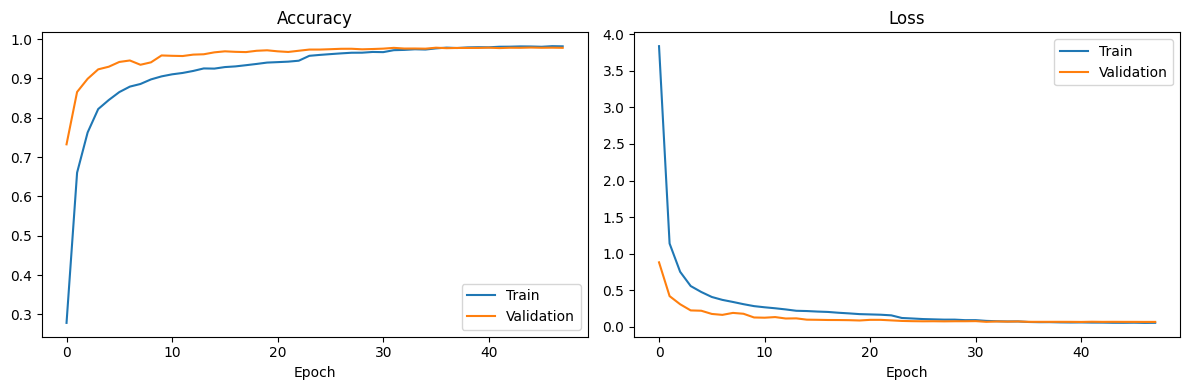

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
Y_pred_proba = model.predict(X_val, batch_size=128, verbose=1)

def top_k_accuracy(y_true, y_pred_proba, k):
    top_k = np.argsort(y_pred_proba, axis=1)[:, -k:]
    return np.mean([y_true[i] in top_k[i] for i in range(len(y_true))])

for k in [1, 3, 5, 10]:
    print(f"Top-{k} accuracy : {top_k_accuracy(Y_val, Y_pred_proba, k):.4f}")

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Top-1 accuracy : 0.9782
Top-3 accuracy : 0.9980
Top-5 accuracy : 0.9997
Top-10 accuracy : 1.0000


In [25]:
model = tf.keras.models.load_model('/content/drive/MyDrive/IA RMN/mon_modele_tf 13C/2_modele_RMN13C.h5')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(list(molecules_dict_clean.keys()))

def predire_molecule(csv_path, model, le, points, augmentation=True):
    df = pd.read_csv(csv_path)[['ppm', 'Int.']]
    df['ppm'] = pd.to_numeric(df['ppm'], errors='coerce')
    df['Int.'] = pd.to_numeric(df['Int.'], errors='coerce')
    df.dropna(subset=['ppm', 'Int.'], inplace=True)
    df = normaliser_intensites(df)

    if augmentation:
        X_rand = np.random.uniform(-1.0, 1.0)
        Y_rand = np.random.uniform(0.8, 1.2)
        largeur = np.random.uniform(0.015, 0.025)
    else:
        X_rand, Y_rand, largeur = 0.0, 1.0, 0.02

    spectre = crpic_vectorise(points,
                          df['ppm'].values + X_rand,
                          df['Int.'].values * Y_rand,
                          largeur)

    if augmentation:
      amplitude_max = np.max(spectre)
      snr = 10 ** np.random.uniform(np.log10(150), np.log10(500))
      bruit_std = amplitude_max / snr
      Gres = np.random.normal(0, bruit_std, len(points))
    else:
      Gres = np.zeros(len(points))

    spectre += Gres

    spectre_pret = spectre[np.newaxis, ..., np.newaxis].astype(np.float32)
    predictions = model.predict(spectre_pret, verbose=0)

    index_gagnant = np.argmax(predictions)
    nom_molecule = le.inverse_transform([index_gagnant])[0]
    confiance = predictions[0][index_gagnant] * 100

    print(f"Molécule prédite : {nom_molecule}")
    print(f"Confiance        : {confiance:.2f}%")
    print("\nTop 3 :")
    top3 = np.argsort(predictions[0])[::-1][:3]
    for i in top3:
        print(f"  {le.inverse_transform([i])[0]:<30} {predictions[0][i]*100:.2f}%")

# Exemple
predire_molecule('/content/drive/MyDrive/IA RMN/Molecules CSV 13C test/DCM.csv', model, le, points)

Molécule prédite : DCM
Confiance        : 51.05%

Top 3 :
  DCM                            51.05%
  Methanol                       44.46%
  1_2-Dichloroethane             3.59%
